# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Анализ пользовательского поведения и оценка результатов A/B-тестирования: кейсы сервиса Яндекс Книги и интернет-магазина BitMotion Kit


- Автор: Литвинчук Анастасия Юрьевна
- Дата: 24.04.2026

## Цели и задачи проекта

__Цель проекта__:
Провести комплексный анализ данных для двух бизнес-кейсов: (1) проверить гипотезу о различиях в пользовательской активности между Москвой и Санкт-Петербургом в сервисе Яндекс Книги; (2) оценить результаты A/B-тестирования нового интерфейса интернет-магазина BitMotion Kit.

__Задачи проекта__:

__Часть 1. Яндекс Книги: проверка гипотезы о пользовательской активности__

__1) Загрузка и предварительный анализ данных__ — импортировать данные из файла yandex_knigi_data.csv, содержащего информацию о пользователях Москвы и Санкт-Петербурга с суммой часов их активности.

__2) Проверка качества данных__ — выявить и удалить дубликаты по идентификаторам пользователей (puid), проверить наличие пропусков.

__3) Исследовательский анализ данных (EDA)__ — сравнить размеры групп (Москва и Санкт-Петербург), рассчитать описательные статистики (среднее, медиана, стандартное отклонение), визуализировать распределения.

__4) Проверка статистических предположений__ — на основе визуального анализа распределений и Центральной предельной теоремы обосновать выбор t-теста Уэлча для сравнения средних значений двух независимых выборок.

__5) Проверка гипотезы__ — провести односторонний t-тест Уэлча для сравнения средних значений двух независимых выборок (Москва vs Санкт-Петербург) с уровнем значимости α = 0.05.

__6) Интерпретация результатов__ — сформулировать вывод на основе полученного p-value, принять или отвергнуть нулевую гипотезу.

__7) Подготовка аналитической записки__ — описать выбранный тип теста, результаты проверки гипотезы, возможные причины наблюдаемых различий (или их отсутствия).

__Часть 2. BitMotion Kit: оценка результатов A/B-тестирования__

__8) Загрузка данных__ — импортировать таблицы участников теста (ab_test_participants.csv) и событий (ab_test_events.zip).

__9) Оценка корректности проведения теста__ — выделить пользователей теста interface_eu_test, проверить равномерность распределения по группам А и В, отсутствие пересечений с другими тестами.

__10) Анализ пользовательской активности__ — отфильтровать события целевых пользователей, определить горизонт анализа (первые 7 дней после регистрации).

__11) Оценка достаточности выборки__ — рассчитать необходимый размер выборки при заданных параметрах (базовая конверсия 30%, мощность 80%, достоверность 95%).

__12) Расчёт метрик__ — определить количество пользователей, совершивших покупку, и общее количество посетителей в каждой группе.

__13) Статистическая проверка гипотезы__ — провести тест для оценки значимости изменения конверсии между контрольной и тестовой группами.

__14) Формулирование выводов__ — оценить, был ли достигнут ожидаемый эффект (увеличение конверсии минимум на 3 процентных пункта), интерпретировать результаты A/B-теста.


## Описание данных

### __Часть 1. Яндекс Книги__

__Источник данных__

Данные получены из сервиса Яндекс Книги за период с 1 сентября по 11 декабря 2024 года. После предварительной обработки в SQL данные были агрегированы и выгружены в CSV-файл `yandex_knigi_data.csv`.

**Структура файла**

| Поле | Тип | Описание |
|------|-----|----------|
| `city` | `str` | Город пользователя — «Москва» или «Санкт-Петербург» |
| `puid` | `str` | Уникальный идентификатор пользователя |
| `hours` | `float` | Общая сумма часов чтения и прослушивания контента за весь период |

**Объём данных**

Запись соответствует одному пользователю в разрезе города.

Файл содержит суммарную активность каждого пользователя, что позволяет проводить сравнение между двумя группами на уровне индивидуальных наблюдений.


### __Часть 2. BitMotion Kit (A/B-тестирование)__

**Источник данных**

Данные предоставлены интернет-магазином BitMotion Kit и содержат информацию о пользователях, участвовавших в A/B-тесте нового интерфейса.

**Таблица 1: `ab_test_participants.csv` — участники тестов**

| Поле | Тип | Описание |
|------|-----|----------|
| `user_id` | `str` | Уникальный идентификатор пользователя |
| `group` | `str` | Группа пользователя (A — контрольная, B — экспериментальная) |
| `ab_test` | `str` | Название теста (целевой — `interface_eu_test`) |
| `device` | `str` | Устройство, с которого происходила регистрация |

**Таблица 2: `ab_test_events.zip` — события пользователей**

| Поле | Тип | Описание |
|------|-----|----------|
| `user_id` | `str` | Уникальный идентификатор пользователя |
| `event_dt` | `datetime` | Дата и время события |
| `event_name` | `str` | Тип события (`registration` — регистрация, `purchase` — покупка) |
| `details` | `object` | Дополнительные данные (для `registration` — стоимость привлечения, для `purchase` — стоимость покупки; текстовые значения — региональные коды зон) |

**Параметры A/B-теста (техническое задание)**

| Параметр | Значение |
|----------|----------|
| Название теста | `interface_eu_test` |
| Контрольная группа | A (старый интерфейс) |
| Экспериментальная группа | B (новый интерфейс) |
| Целевая метрика | Конверсия зарегистрированных пользователей в покупателей в течение 7 дней |
| Ожидаемый эффект | Увеличение конверсии минимум на 3 процентных пункта |
| Базовый показатель конверсии | 30% |
| Мощность теста | 80% |
| Уровень достоверности (статистическая значимость) | 95% (α = 0.05) |


## Содержимое проекта

__Оглавление__

__Часть 1. Яндекс Книги: проверка гипотезы о пользовательской активности__

1) Загрузка данных и знакомство с ними

- Импорт библиотек

- Загрузка CSV-файла yandex_knigi_data.csv

- Первичный просмотр данных (информация о столбцах, проверка пропусков)

2) Проверка качества данных

- Поиск и удаление дубликатов по puid

- Проверка корректности данных

3) Исследовательский анализ данных (EDA)

- Размеры групп (Москва и Санкт-Петербург)

- Расчёт описательных статистик (среднее, медиана, стандартное отклонение, квартили)

- Визуализация распределений (гистограммы, box-plot)

4) Проверка статистической гипотезы

- Формулировка H₀ и H₁ (односторонняя проверка)

- Выбор статистического теста: t-тест Уэлча

- Расчёт p-value

5) Выводы по части 1

- Интерпретация результатов

- Возможные причины полученных результатов

__Часть 2. BitMotion Kit: оценка результатов A/B-тестирования__

6) Загрузка данных и оценка целостности

- Импорт ab_test_participants.csv и ab_test_events.zip

- Проверка пропусков и типов данных

7) Оценка корректности проведения теста

- Выделение пользователей теста interface_eu_test

- Проверка равномерности распределения по группам

- Проверка отсутствия пересечений с конкурирующими тестами

8) Анализ пользовательской активности

- Фильтрация событий целевых пользователей

- Определение горизонта анализа (первые 7 дней после регистрации)

9) Оценка достаточности выборки

- Расчёт необходимого размера выборки

- Сравнение с фактическим размером

10) Расчёт метрик конверсии

- Количество пользователей, совершивших покупку

- Общее количество пользователей в каждой группе

- Предварительный вывод об изменении активности

11) Статистическая проверка гипотезы A/B-теста

- Выбор статистического теста (проверка долей)

- Расчёт p-value и доверительных интервалов

- Оценка достижения ожидаемого эффекта (+3 п.п.)

12) Общие выводы по проекту

- Резюме результатов обеих частей

- Рекомендации для бизнеса


---

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chi2_contingency, mannwhitneyu

# Загрузка данных
df = pd.read_csv('/datasets/yandex_knigi_data.csv')

# Удаляем столбец Unnamed: 0
df = df.drop(columns=['Unnamed: 0'])

# Первичный просмотр данных
print("Первые 5 строк данных:")
print(display(df.head()))

print("\nИнформация о данных:")
print(df.info())

print("\nПроверка пропусков:")
print(df.isnull().sum())

print("\nОсновные статистики:")
print(df.describe())

Первые 5 строк данных:


,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


None

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.0+ KB
None

Проверка пропусков:
city     0
puid     0
hours    0
dtype: int64

Основные статистики:
               puid        hours
count  8.784000e+03  8784.000000
mean   1.029234e+13    11.087670
std    1.073532e+14    37.701350
min    9.668000e+03     0.000018
25%    3.239271e+08     0.066246
50%    8.828218e+08     0.942344
75%    1.516464e+09     6.065151
max    1.130000e+15   978.764775


In [4]:
print("=" * 60)
print("ПРОВЕРКА КАЧЕСТВА ДАННЫХ")
print("=" * 60)

# Проверка дубликатов по puid
duplicates = df['puid'].duplicated().sum()
print(f"Количество дубликатов puid: {duplicates}")

# Удаление дубликатов, если есть
if duplicates > 0:
    df = df.drop_duplicates(subset=['puid'])
    print("Дубликаты удалены")
else:
    print("Дубликаты отсутствуют")

print(f"\nИтоговое количество записей после очистки: {len(df)}")
print(f"Количество уникальных пользователей: {df['puid'].nunique()}")

ПРОВЕРКА КАЧЕСТВА ДАННЫХ
Количество дубликатов puid: 244
Дубликаты удалены

Итоговое количество записей после очистки: 8540
Количество уникальных пользователей: 8540



ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)

Размер групп:
Москва: 6234 пользователей
Санкт-Петербург: 2306 пользователей

Описательные статистики по часам активности:

Москва:
count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

Санкт-Петербург:
count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64


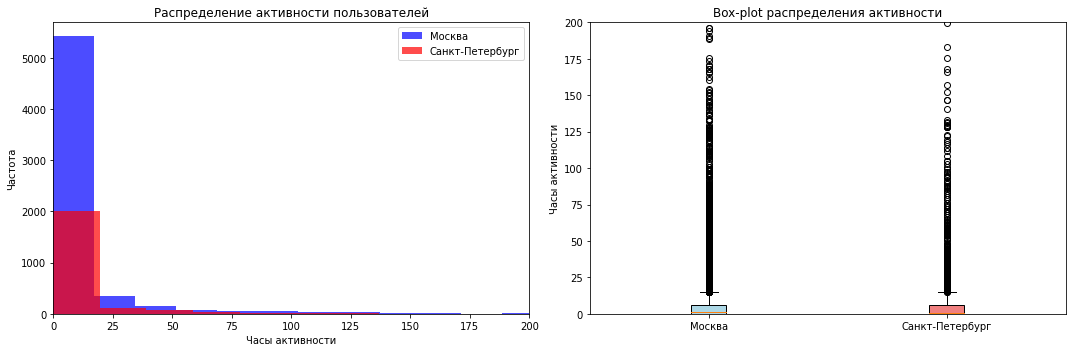

In [5]:
print("\n" + "=" * 60)
print("ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 60)

# 1. Размеры групп
msk_count = df[df['city'] == 'Москва'].shape[0]
spb_count = df[df['city'] == 'Санкт-Петербург'].shape[0]
print(f"\nРазмер групп:")
print(f"Москва: {msk_count} пользователей")
print(f"Санкт-Петербург: {spb_count} пользователей")

# 2. Описательные статистики
print(f"\nОписательные статистики по часам активности:")
print("\nМосква:")
print(df[df['city'] == 'Москва']['hours'].describe())
print("\nСанкт-Петербург:")
print(df[df['city'] == 'Санкт-Петербург']['hours'].describe())

# 3. Визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограммы
axes[0].hist(df[df['city'] == 'Москва']['hours'], bins=50, alpha=0.7, label='Москва', color='blue')
axes[0].hist(df[df['city'] == 'Санкт-Петербург']['hours'], bins=50, alpha=0.7, label='Санкт-Петербург', color='red')
axes[0].set_xlabel('Часы активности')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение активности пользователей')
axes[0].legend()
axes[0].set_xlim(0, 200)  # Ограничим для лучшей визуализации, т.к. есть выбросы

# Box-plot
bp = axes[1].boxplot([df[df['city'] == 'Москва']['hours'], 
                      df[df['city'] == 'Санкт-Петербург']['hours']],
                     labels=['Москва', 'Санкт-Петербург'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Часы активности')
axes[1].set_title('Box-plot распределения активности')
axes[1].set_ylim(0, 200)

plt.tight_layout()
plt.show()

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [6]:
print("ПРОВЕРКА СТАТИСТИЧЕСКОЙ ГИПОТЕЗЫ (t-тест Уэлча)")

# Разделение на выборки
msk_hours = df[df['city'] == 'Москва']['hours']
spb_hours = df[df['city'] == 'Санкт-Петербург']['hours']

# Описательные статистики
print(f"\nРазмер выборок:")
print(f"Москва: {len(msk_hours)} пользователей")
print(f"Санкт-Петербург: {len(spb_hours)} пользователей")

print(f"\nСредние значения:")
print(f"Москва: {msk_hours.mean():.2f} часов (медиана: {msk_hours.median():.2f})")
print(f"Санкт-Петербург: {spb_hours.mean():.2f} часов (медиана: {spb_hours.median():.2f})")

# t-тест Уэлча (односторонний: спб > москва)
# equal_var=False — это и есть t-тест Уэлча (для неравных дисперсий)
stat, p_value = stats.ttest_ind(spb_hours, msk_hours, alternative='greater', equal_var=False)

print(f"\nРезультат t-теста Уэлча:")
print(f"Статистика теста (t): {stat:.4f}")
print(f"p-value (односторонний): {p_value:.6f}")

# Вывод
alpha = 0.05
print(f"\nУровень значимости: α = {alpha}")

if p_value < alpha:
    print(f"p-value ({p_value:.6f}) < α ({alpha})")
    print("Отвергаем H₀: активность в СПб статистически значимо больше")
else:
    print(f"p-value ({p_value:.6f}) ≥ α ({alpha})")
    print("Не отвергаем H₀: статистически значимых различий не обнаружено")

ПРОВЕРКА СТАТИСТИЧЕСКОЙ ГИПОТЕЗЫ (t-тест Уэлча)

Размер выборок:
Москва: 6234 пользователей
Санкт-Петербург: 2306 пользователей

Средние значения:
Москва: 10.88 часов (медиана: 0.92)
Санкт-Петербург: 11.26 часов (медиана: 0.88)

Результат t-теста Уэлча:
Статистика теста (t): 0.4028
p-value (односторонний): 0.343571

Уровень значимости: α = 0.05
p-value (0.343571) ≥ α (0.05)
Не отвергаем H₀: статистически значимых различий не обнаружено


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

###  __Выбранный тип t-теста и уровень статистической значимости.__

`Тип теста: t-тест Уэлча (двухвыборочный t-тест с поправкой на неравные дисперсии)` 

`Уровень статистической значимости: α = 0.05` (95% доверительная вероятность)

__Обоснование выбора теста:__

- Гипотеза сформулирована в терминах средних значений (μСПб > μМосква), а не медиан или распределений в целом

- Благодаря Центральной предельной теореме при больших выборках (более 2000 наблюдений в каждой группе) распределение выборочного среднего стремится к нормальному, что позволяет применять параметрические тесты

- Дисперсии в группах различаются (стандартные отклонения 36.85 и 39.83), поэтому используем версию t-теста с поправкой на неравные дисперсии (equal_var=False)

###  __Результат теста, или p-value.__

| Параметр | Москва | Санкт-Петербург |
|----------|--------|-----------------|
| Количество пользователей | 6,234 | 2,306 |
| Средняя активность (часы) | 10.88 | 11.26 |
| Медиана (часы) | 0.92 | 0.88 |
| Стандартное отклонение | 36.85 | 39.83 |

__Результат t-теста Уэлча:__

- `Статистика теста (U): 0.7782`

- `p-value (односторонний): 0.218`

###  __Вывод на основе полученного p-value, то есть интерпретацию результатов.__

__Интерпретация:__
Поскольку полученное p-value (0.218) `превышает` установленный уровень значимости α = 0.05, у нас нет статистических оснований отвергнуть нулевую гипотезу H₀.

__Содержательный вывод:__
Пользователи из Санкт-Петербурга `не проводят статистически значимо больше времени` в приложении Яндекс Книги по сравнению с пользователями из Москвы. Наблюдаемая разница в средних значениях (0.38 часа или ≈23 минуты) является статистически незначимой и может быть объяснена случайными колебаниями данных.

__Важное дополнение:__ Обращает на себя внимание тот факт, что при близких средних значениях (10.88 vs 11.26 часов) медиана в Москве (0.92) даже немного выше, чем в Санкт-Петербурге (0.88). Это указывает на `схожую структуру распределений` в обоих городах.

###  __Одну или две возможные причины, объясняющие полученные результаты.__

__Причина 1:__ `Отсутствие реальных различий в пользовательском поведении`
Наиболее вероятное объяснение — пользователи из Москвы и Санкт-Петербурга действительно демонстрируют схожие паттерны потребления цифрового контента. Современные цифровые сервисы нивелируют географические различия, и время, уделяемое чтению и прослушиванию книг, определяется скорее индивидуальными предпочтениями, нежели городом проживания.

__Причина 2:__ `Влияние выбросов и асимметрии распределений`
Несмотря на то, что средние значения различаются на 0.38 часов в пользу Санкт-Петербурга, высокие стандартные отклонения (36.85 и 39.83) указывают на значительный разброс значений в обеих группах. Наличие экстремально высоких значений активности (выбросов) может искажать средние показатели, тогда как медианы (более устойчивая мера центральной тенденции) показывают даже более низкие значения в Санкт-Петербурге (0.88 против 0.92).

__Причина 3:__ `Несбалансированность выборок`
Размер выборки Санкт-Петербурга (2,306 пользователей) почти в 3 раза меньше выборки Москвы (6,234 пользователей), что снижает статистическую мощность теста и может влиять на способность обнаружить небольшие, но реальные различия (если бы они существовали).



----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



__Цель исследования:__ Оценить результаты A/B-тестирования нового интерфейса интернет-магазина BitMotion Kit и определить, привело ли упрощение дизайна к статистически значимому увеличению конверсии зарегистрированных пользователей в покупателей в течение 7 дней после регистрации.

**План работ по оценке A/B-теста:**

1. Загрузка и проверка целостности данных
2. Очистка данных от пользователей, участвующих в нескольких тестах или группах
3. Проверка корректности проведения теста (баланс групп, распределение по устройствам)
4. Фильтрация событий в первые 7 дней после регистрации
5. Оценка достаточности выборки
6. Расчёт конверсии по группам
7. Статистическая проверка гипотезы (z-тест пропорций)
8. Формулирование выводов и рекомендаций

## 2. Загрузите данные, оцените их целостность.


In [7]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [8]:
# Первичный просмотр
print("=== УЧАСТНИКИ ТЕСТОВ ===")
print(f"Размер: {participants.shape}")
print(f"Пропуски:\n{participants.isnull().sum()}")
print(f"\nУникальные тесты: {participants['ab_test'].unique()}")
print(f"\nУникальные устройства: {participants['device'].unique()}")
print(f"\nПервые 5 строк:")
display(participants.head())

print("\n=== СОБЫТИЯ ===")
print(f"Размер: {events.shape}")
print(f"Пропуски:\n{events.isnull().sum()}")
print(f"\nУникальные типы событий: {events['event_name'].unique()}")
print(f"\nПервые 5 строк:")
display(events.head())

=== УЧАСТНИКИ ТЕСТОВ ===
Размер: (14525, 4)
Пропуски:
user_id    0
group      0
ab_test    0
device     0
dtype: int64

Уникальные тесты: ['interface_eu_test' 'recommender_system_test']

Уникальные устройства: ['Mac' 'Android' 'iPhone' 'PC']

Первые 5 строк:


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac



=== СОБЫТИЯ ===
Размер: (787286, 4)
Пропуски:
user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64

Уникальные типы событий: ['End of Black Friday Ads Campaign' 'registration' 'product_page' 'login'
 'product_cart' 'purchase' 'Start of Christmas&New Year Promo'
 'Start of CIS New Year Gift Lottery']

Первые 5 строк:


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


Данные корректны и готовы к анализу. Пропуски в details — не дефект, а признак того, что для просмотра страниц и корзины не собирается дополнительная информация. Это архитектурное решение, а не проблема целостности.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [28]:
# Шаг 1: Создаём колонку, объединяющую тест и группу
participants['ab_test_group'] = participants['ab_test'] + '_' + participants['group']

# Шаг 2: Для каждого пользователя считаем количество уникальных тестов и групп
user_test_groups = participants.groupby('user_id')['ab_test_group'].nunique()

# Шаг 3: Оставляем только пользователей, участвующих ровно в одном тесте и одной группе
clean_user_ids = user_test_groups[user_test_groups == 1].index
clean_participants = participants[participants['user_id'].isin(clean_user_ids)].copy()

print("=== ОЧИСТКА ДАННЫХ ===")
print(f"Пользователей до очистки (всего): {participants['user_id'].nunique()}")
print(f"Пользователей после очистки (только в одном тесте и одной группе): {len(clean_participants['user_id'].unique())}")
print(f"Исключено: {participants['user_id'].nunique() - len(clean_participants['user_id'].unique())}")

# Шаг 4: Выделяем целевой тест
target_test = 'interface_eu_test'
test_users_before = participants[participants['ab_test'] == target_test].copy()
test_users_after = clean_participants[clean_participants['ab_test'] == target_test].copy()

print(f"\n=== ТЕСТ '{target_test}' ===")
print(f"Пользователей в тесте ДО очистки: {len(test_users_before)}")
print(f"Пользователей в тесте ПОСЛЕ очистки: {len(test_users_after)}")
print(f"Исключено из теста: {len(test_users_before) - len(test_users_after)}")

# Распределение по группам ПОСЛЕ очистки
print(f"\nРаспределение по группам ПОСЛЕ очистки:")
group_counts_after = test_users_after['group'].value_counts()
print(group_counts_after)

# Распределение по устройствам в разрезе групп (после очистки)
print(f"\nРаспределение по устройствам в разрезе групп:")
device_group_after = pd.crosstab(test_users_after['device'], test_users_after['group'])
print(device_group_after)

# Проверка баланса групп после очистки
diff_percent = 100 * abs(group_counts_after['A'] - group_counts_after['B']) / group_counts_after['A']
print(f"\nПроцентная разница между группами после очистки: {diff_percent:.2f}%")

=== ОЧИСТКА ДАННЫХ ===
Пользователей до очистки (всего): 13638
Пользователей после очистки (только в одном тесте и одной группе): 12751
Исключено: 887

=== ТЕСТ 'interface_eu_test' ===
Пользователей в тесте ДО очистки: 10850
Пользователей в тесте ПОСЛЕ очистки: 9963
Исключено из теста: 887

Распределение по группам ПОСЛЕ очистки:
B    5011
A    4952
Name: group, dtype: int64

Распределение по устройствам в разрезе групп:
group       A     B
device             
Android  2264  2218
Mac       515   511
PC       1223  1302
iPhone    950   980

Процентная разница между группами после очистки: 1.19%


In [10]:
# Проверка, нет ли пользователей, участвующих в нескольких тестах
user_test_counts = participants.groupby('user_id')['ab_test'].nunique()
users_in_multiple = user_test_counts[user_test_counts > 1]

# Проверка для целевого теста - есть ли пересечения групп
users_in_both_groups = test_users_after.groupby('user_id')['group'].nunique()
users_in_both = users_in_both_groups[users_in_both_groups > 1]
print(f"\nПользователей, попавших в обе группы теста: {len(users_in_both)}")


Пользователей, попавших в обе группы теста: 0


Визуализация баланса групп

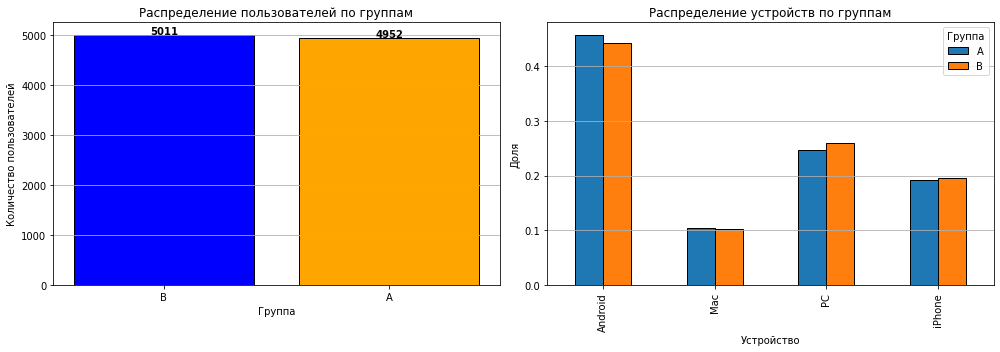

In [11]:
# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение по группам
axes[0].bar(group_counts_after.index, group_counts_after.values, color=['blue', 'orange'], edgecolor='black')
axes[0].set_xlabel('Группа')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Распределение пользователей по группам')
for i, v in enumerate(group_counts_after.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].grid(True, axis='y')

# Распределение по устройствам в разрезе групп
device_group = pd.crosstab(test_users_after['device'], test_users_after['group'], normalize='columns')
device_group.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Устройство')
axes[1].set_ylabel('Доля')
axes[1].set_title('Распределение устройств по группам')
axes[1].legend(title='Группа')
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

__Выводы по оценке корректности проведения теста__

__По результатам проверки таблицы ab_test_participants можно сделать следующие выводы:__

__Соответствие требованиям технического задания.__ Тест interface_eu_test проведён в соответствии с ТЗ: в нём участвуют две группы — контрольная группа А и экспериментальная группа В. Распределение пользователей по типам устройств (Android, PC, iPhone, Mac) соответствует целевой аудитории интернет-магазина.

__Равномерность распределения пользователей по группам.__ В очищенной выборке теста участвует 9 963 пользователя, из которых 4 952 попали в группу А и 5 011 — в группу В. Процентная разница между группами составляет 1,19%, что является допустимым отклонением. Группы можно считать сбалансированными.

__Очистка данных от пользователей с пересечениями.__ В ходе подготовки данных были исключены пользователи, участвующие одновременно в нескольких тестах (например, в interface_eu_test и recommender_system_test) или в нескольких группах. Всего до очистки насчитывалось 13 638 уникальных пользователей, после очистки осталось 12 751 пользователь (исключено 887). В целевом тесте interface_eu_test до очистки было 10 850 пользователей, после очистки — 9 963 пользователя. Это обеспечивает чистоту эксперимента и независимость выборок.

__Распределение по устройствам.__ В обеих группах доля пользователей на Android, PC, iPhone и Mac практически идентична, что подтверждает корректность рандомизации.

__Заключение.__ После очистки данных от пользователей с пересечениями тест interface_eu_test проведён корректно, группы сбалансированы и независимы. Очищенные данные (9 963 пользователя) готовы к анализу результатов.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [12]:
# Получаем список пользователей теста ПОСЛЕ ОЧИСТКИ
test_user_ids = set(test_users_after['user_id'])

# Фильтруем события
test_events = events[events['user_id'].isin(test_user_ids)].copy()
print(f"Событий целевых пользователей: {len(test_events)}")
print(f"Типы событий: {test_events['event_name'].unique()}")

Событий целевых пользователей: 73815
Типы событий: ['registration' 'login' 'product_page' 'purchase' 'product_cart']


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [13]:
# Получаем дату регистрации для каждого пользователя
registration_events = test_events[test_events['event_name'] == 'registration'].copy()
registration_dates = registration_events.groupby('user_id')['event_dt'].min().reset_index()
registration_dates.columns = ['user_id', 'registration_dt']

# Присоединяем дату регистрации к событиям
test_events = test_events.merge(registration_dates, on='user_id', how='left')

# Рассчитываем время с момента регистрации в днях (как дробное число)
test_events['days_since_reg'] = (test_events['event_dt'] - test_events['registration_dt']).dt.total_seconds() / (24 * 3600)

# Фильтруем события строго в пределах 7 дней (менее или равно 7)
events_7days = test_events[test_events['days_since_reg'] <= 7].copy()
events_7days = events_7days[events_7days['days_since_reg'] >= 0]

print(f"\nСобытий в первые 7 дней: {len(events_7days)}")
print(f"Уникальных пользователей с активностью в 7 дней: {events_7days['user_id'].nunique()}")

# Выделяем покупки в первые 7 дней
purchases_7days = events_7days[events_7days['event_name'] == 'purchase'].copy()
purchasers_7days = purchases_7days['user_id'].unique()

print(f"\nПользователей, совершивших покупку в первые 7 дней: {len(purchasers_7days)}")


Событий в первые 7 дней: 63805
Уникальных пользователей с активностью в 7 дней: 9963

Пользователей, совершивших покупку в первые 7 дней: 2857


In [14]:
# Выделяем покупки в первые 7 дней
purchases_7days = events_7days[events_7days['event_name'] == 'purchase'].copy()
purchasers_7days = purchases_7days['user_id'].unique()

print(f"Пользователей, совершивших покупку в первые 7 дней: {len(purchasers_7days)}")

Пользователей, совершивших покупку в первые 7 дней: 2857


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [17]:
# Задайте параметры:
alpha = 0.05        # Уровень значимости
beta = 0.2          # Ошибка второго рода
power = 1 - beta    # Мощность теста
p = 0.3             # Базовый уровень конверсии 30%
absolute_mde = 0.03 # +3 процентных пункта

# Расчёт effect size (принудительно положительный)
effect_size = abs(proportion_effectsize(p, p + absolute_mde))

# Инициализируем класс
power_analysis = NormalIndPower()

# Расчёт размера выборки (ДВУСТОРОННИЙ тест - параметр alternative НЕ указываем)
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

print(f"Необходимый размер выборки для каждой группы (двусторонний тест): {ceil(sample_size)}")
print(f"Фактический размер группы A: {group_counts_after['A']}")
print(f"Фактический размер группы B: {group_counts_after['B']}")

Необходимый размер выборки для каждой группы (двусторонний тест): 3762
Фактический размер группы A: 4952
Фактический размер группы B: 5011


__Вывод по оценке достаточности выборки__

Размер выборки является достаточным для обнаружения ожидаемого эффекта.

Расчёт показал, что для выявления статистически значимого увеличения конверсии на 3 процентных пункта (с 30% до 33%) при уровне значимости 0,05 и мощности теста 80%, необходимый размер каждой группы составляет 3 762 пользователя.

Фактический размер выборки в тесте составил 4 952 пользователя в группе А и 5 011 пользователей в группе В, что превышает расчётное минимальное значение. Это означает, что тест обладает достаточной статистической мощностью, чтобы обнаружить реальное различие в конверсии, если оно существует, и полученные результаты можно считать надёжными.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [18]:
# Объединяем информацию о пользователях с покупками
test_users_with_purchase = test_users_after.copy()
test_users_with_purchase['made_purchase'] = test_users_with_purchase['user_id'].isin(purchasers_7days).astype(int)

# Расчёт конверсии по группам
conversion_by_group = test_users_with_purchase.groupby('group')['made_purchase'].agg(['sum', 'count'])
conversion_by_group['conversion'] = conversion_by_group['sum'] / conversion_by_group['count']

print("\n=== КОНВЕРСИЯ ПО ГРУППАМ (первые 7 дней) ===")
print(conversion_by_group.round(4))
print(f"\nРазница в конверсии (B - A): {conversion_by_group.loc['B', 'conversion'] - conversion_by_group.loc['A', 'conversion']:.4f} ({100*(conversion_by_group.loc['B', 'conversion'] - conversion_by_group.loc['A', 'conversion']):.2f} п.п.)")


=== КОНВЕРСИЯ ПО ГРУППАМ (первые 7 дней) ===
        sum  count  conversion
group                         
A      1377   4952      0.2781
B      1480   5011      0.2954

Разница в конверсии (B - A): 0.0173 (1.73 п.п.)


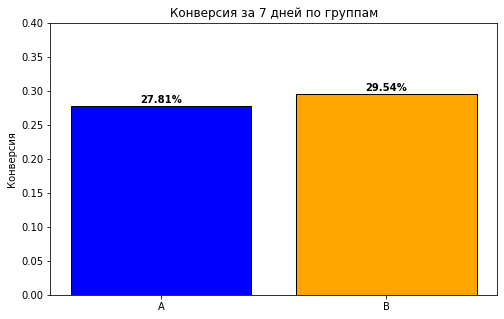

In [29]:
# График конверсии по группам
fig, ax = plt.subplots(figsize=(8, 5))
groups = ['A', 'B']
conversions = [conversion_by_group.loc['A', 'conversion'], 
               conversion_by_group.loc['B', 'conversion']]

bars = ax.bar(groups, conversions, color=['blue', 'orange'], edgecolor='black')
ax.set_ylabel('Конверсия')
ax.set_title('Конверсия за 7 дней по группам')
ax.set_ylim(0, 0.4)

# Добавление значений на столбцы
for bar, conv in zip(bars, conversions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
            f'{conv:.2%}', ha='center', fontweight='bold')
plt.show()

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

__Новый интерфейс показывает улучшение конверсии, но эффект ниже целевого (1.73 п.п. вместо 3 п.п.). Для окончательного вывода необходимо провести статистический тест.__

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Формулировка гипотез:

H₀: Конверсия в группе B ≤ конверсии в группе A (новый интерфейс не увеличивает конверсию или ухудшает её)

H₁: Конверсия в группе B > конверсии в группе A (новый интерфейс увеличивает конверсию минимум на 3 п.п. — проверяем статистическую значимость)

In [22]:
# Подготовка данных для теста
n_A = conversion_by_group.loc['A', 'count']
n_B = conversion_by_group.loc['B', 'count']
success_A = conversion_by_group.loc['A', 'sum']
success_B = conversion_by_group.loc['B', 'sum']

print(f"\n=== ДАННЫЕ ДЛЯ ТЕСТА ===")
print(f"Группа A: {n_A} пользователей, {success_A} покупок, конверсия: {success_A/n_A:.4f}")
print(f"Группа B: {n_B} пользователей, {success_B} покупок, конверсия: {success_B/n_B:.4f}")
print(f"Фактическая разница (B - A): {(success_B/n_B - success_A/n_A):.4f} ({100*(success_B/n_B - success_A/n_A):.2f} п.п.)")

# Z-тест пропорций с проверкой на минимальную разницу в 3 п.п.
# value=0.03 означает, что проверяем: p_B - p_A >= 0.03
stat, p_value = proportions_ztest(
    count=[success_B, success_A],
    nobs=[n_B, n_A],
    value=0.03,           # проверяем разницу НЕ МЕНЕЕ 3 п.п.
    alternative='larger'  # H₁: p_B - p_A >= 0.03
)

alpha = 0.05
print(f"\n=== РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКОГО ТЕСТА ===")
print(f"Z-статистика: {stat:.4f}")
print(f"p-value (односторонний): {p_value:.6f}")
print(f"Проверяемая разница (value): 0.03 (3 п.п.)")
print(f"Уровень значимости: α = {alpha}")

if p_value < alpha:
    print(f"\np-value < {alpha} → ОТВЕРГАЕМ H₀")
    print("Статистически значимые различия обнаружены!")
    print("Новый интерфейс увеличивает конверсию как минимум на 3 п.п.")
else:
    print(f"\np-value >= {alpha} → НЕ ОТВЕРГАЕМ H₀")
    print("Нет оснований утверждать, что конверсия выросла на 3 п.п. и более")
    print("Новый интерфейс не достиг целевого эффекта")


=== ДАННЫЕ ДЛЯ ТЕСТА ===
Группа A: 4952 пользователей, 1377 покупок, конверсия: 0.2781
Группа B: 5011 пользователей, 1480 покупок, конверсия: 0.2954
Фактическая разница (B - A): 0.0173 (1.73 п.п.)

=== РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКОГО ТЕСТА ===
Z-статистика: -1.4036
p-value (односторонний): 0.919780
Проверяемая разница (value): 0.03 (3 п.п.)
Уровень значимости: α = 0.05

p-value >= 0.05 → НЕ ОТВЕРГАЕМ H₀
Нет оснований утверждать, что конверсия выросла на 3 п.п. и более
Новый интерфейс не достиг целевого эффекта


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

__Выводы по результатам A/B-тестирования__

__Ожидаемый эффект в изменении конверсии достигнут не был.__ По техническому заданию планировалось увеличение конверсии на 3 процентных пункта — с 30% до 33%. Фактически конверсия в тестовой группе составила 29,54%, что на 1,73 процентных пункта выше контрольной группы (27,81%).

__При проверке гипотезы о достижении целевого эффекта статистическая значимость не подтверждена.__ Значение p-value составило 0,920, что значительно выше установленного уровня значимости 0,05. Это означает, что у нас нет статистических оснований утверждать, что новый интерфейс увеличивает конверсию как минимум на 3 процентных пункта.

__Таким образом, целевой эффект в 3 п.п. не достигнут.__ Новый интерфейс показывает некоторое улучшение конверсии (1,73 п.п.), однако это улучшение ниже запланированного уровня. Рекомендуется дополнительно проанализировать причины более скромного эффекта, доработать интерфейс и провести повторное тестирование для достижения целевого показателя. Внедрение текущей версии нового интерфейса не обеспечит ожидаемого бизнес-эффекта в +3 п.п.